# Exam Project

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import Problem1, Problem2

## Problem 3

In [2]:
# importing the PortfolioModelClass from the PortfolioModel module
from PortfolioModel import PortfolioModelClass 

### Question 3.1

In this question, we simulate the return on the risky asset using the given parameters, and check that the simulated returns match the model. We then make a figure showing the distribution of returns and how the value of an investment develops over time, for both the risky and the safe asset.

In [3]:
# Creating the portfolio model with the given parameters 

model = PortfolioModelClass()
print(model)

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


In [4]:
# Creating 50 000 random returns from the model

R = model.draw_returns()

# Simulating risky asset returns and checking that the simulated values are consistent with the model

mean_log_R = np.mean(np.log(R))
std_log_R = np.std(np.log(R))
mean_R = np.mean(R)
theoretical_mean_R = np.exp(model.par.mu + 0.5*model.par.sigma**2)

print(f'mean log R = {np.mean(np.log(R)):.4f} vs mu = {model.par.mu:.4f}')
print(f'std log R = {np.std(np.log(R)):.4f} vs sigma = {model.par.sigma:.4f}')
print(f'mean R = {np.mean(R):.4f} vs exp(mu+0.5*sigma^2): {np.exp(model.par.mu+0.5*model.par.sigma**2):.4f}')

# Checking that the simulated values match the theoretical values within a small tolerance 
     # atol=1e-2 --> allows a small tolerance (0.01) between simulated and theoretical values, since the simulation is based on random draws and will never match exactly

assert np.isclose(mean_log_R, model.par.mu, atol=1e-2), 'mean log R does not match mu' 
assert np.isclose(std_log_R, model.par.sigma, atol=1e-2), 'std log R does not match sigma'
assert np.isclose(mean_R, theoretical_mean_R, atol=1e-2), 'mean R does not match theoretical value'

print('\nTest passed: simulated returns are consistent with the model parameters.')

mean log R = 0.0500 vs mu = 0.0500
std log R = 0.2000 vs sigma = 0.2000
mean R = 1.0725 vs exp(mu+0.5*sigma^2): 1.0725

Test passed: simulated returns are consistent with the model parameters.


The simulated returns are consistent with the model parameters. The mean and standard deviation of the log returns are 0.0500 and 0.2000, which match μ = 0.05 and σ = 0.20. The mean gross return is 1.0725, which also matches the theoretical value.

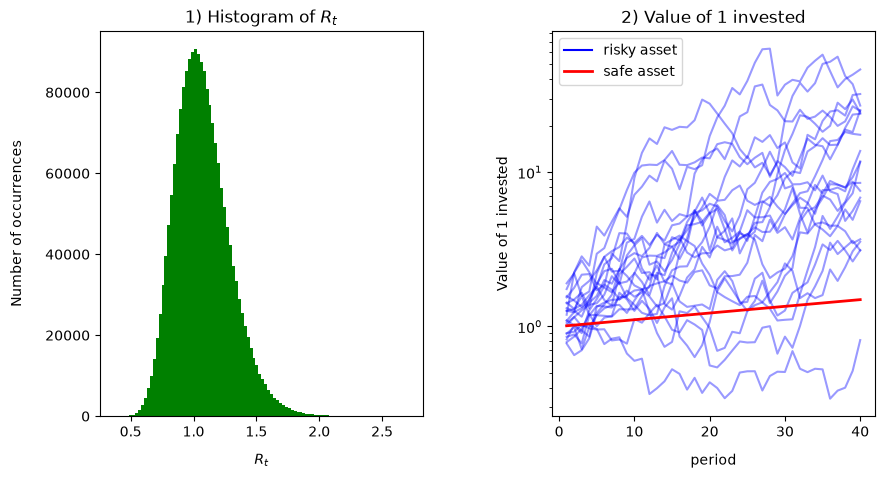

In [5]:
# Creating a figure with two panels 

fig, axes = plt.subplots(1, 2, figsize=(10,5))


# panel 1: histogram of the returns
ax = axes[0]
ax.hist(R.flatten(), bins=100, color='green', alpha=1)
ax.set_title('1) Histogram of $R_t$')
ax.set_xlabel('$R_t$', labelpad = 10)
ax.set_ylabel('Number of occurrences', labelpad = 15)

# panel 2 : value of 1 invested, risky vs safe, for 20 portfolios, log scale
ax = axes[1]

   # Calculate the value of 1 invested in the risky and safe assets
Rf = np.exp(model.par.r)                              # gross return on the safe asset, constant every period
value_risky = np.cumprod(R[:20, :], axis=1)           # shape (20, T)
value_safe = Rf ** np.arange(1, model.par.T + 1)      # shape (T,)

   # Plot the value of 1 invested in the risky and safe assets over time
t = np.arange(1, model.par.T + 1)
ax.plot(t, value_risky.T, color='blue', alpha=0.4)
ax.plot([], [], color='blue', label='risky asset')    # dummy line so the legend shows one entry for all 20 portfolios
ax.plot(t, value_safe, color='red', linewidth=2, label='safe asset')
ax.set_yscale('log')                                  # log scale needed since the risky paths grow at very different rates
ax.set_title('2) Value of 1 invested')
ax.set_xlabel('period', labelpad = 10)
ax.set_ylabel('Value of 1 invested', labelpad = 5)

ax.legend()

fig.subplots_adjust(wspace=0.4)

plt.show()

1) The histogram shows the distribution of simulated returns over 40 periods for 50,000 portfolios. The x-axis represents the returns of the risky asset, while the y-axis represents the frequency of these returns. Most returns are concentrated around the mean, while very low and very high returns are less common. The longer right tail indicates a positive skew, which is characteristic of a lognormal distribution.

2) The figure shows what happens to 1 unit of money invested in the risky asset compared to the safe asset over 40 periods. The blue lines represent the growth of the investment in the risky asset for 20 different portfolios. They all start at around 1 unit of money, but diverge over time due to the randomness of the returns. Some portfolios experience significant growth, while others experience losses. The red line represents the growth of the investment in the safe asset, which grows slowly and predictably due to its constant return. The figure illustrates the potential for higher returns from the risky asset, but also the greater risk and variability compared to the safe asset.





### Question 3.2 

Here we compare the two extreme cases of the trading rule: Delta = 0, where the portfolio is rebalanced to the target share of 50% every period, and Delta = 1, where the portfolio is never traded after the start. In both cases the transaction cost is set to 0, so that the differences are due solely to the trading rule, not to the cost of trading. We use the same drawn returns for both models to ensure a fair comparison. For each rule we report the six numbers required: the number of trades, the average distance to the target, and the mean, median, 10th percentile, and expected utility of terminal wealth

In [6]:
# Trade balanbce, Delta = 0 (always trade)

model_always = PortfolioModelClass(Delta=0.0, tau=0.0)
model_always.simulate(R=R)
summary_always = model_always.summary()

# Trade balance, Delta = 1 (never trade)

model_never = PortfolioModelClass(Delta=1.0, tau=0.0)
model_never.simulate(R=R)
summary_never = model_never.summary()

print('Always trade (Delta=0):')
print(f'  n_trades:  {summary_always.n_trades:.4f}')
print(f'  avg_dist:  {summary_always.avg_dist:.4f}')
print(f'  mean_WT:   {summary_always.mean_WT:.4f}')
print(f'  median_WT: {summary_always.median_WT:.4f}')
print(f'  p10_WT:    {summary_always.p10_WT:.4f}')
print(f'  EU:        {summary_always.EU:.4f}')

print()
print('Never trade (Delta=1):')
print(f'  n_trades:  {summary_never.n_trades:.4f}')
print(f'  avg_dist:  {summary_never.avg_dist:.4f}')
print(f'  mean_WT:   {summary_never.mean_WT:.4f}')
print(f'  median_WT: {summary_never.median_WT:.4f}')
print(f'  p10_WT:    {summary_never.p10_WT:.4f}')
print(f'  EU:        {summary_never.EU:.4f}')

Always trade (Delta=0):
  n_trades:  39.0000
  avg_dist:  0.0394
  mean_WT:   5.0436
  median_WT: 4.0815
  p10_WT:    1.7937
  EU:        -0.0678

Never trade (Delta=1):
  n_trades:  0.0000
  avg_dist:  0.1911
  mean_WT:   8.9756
  median_WT: 4.4478
  p10_WT:    1.4855
  EU:        -0.0767


Never trade gives higher wealth on average, but it also involves more risk. Always trade keeps the portfolio closer to the target and performs better in worse outcomes. It also gives higher expected utility, which means that the risk-averse investor prefers the always-trade strategy.

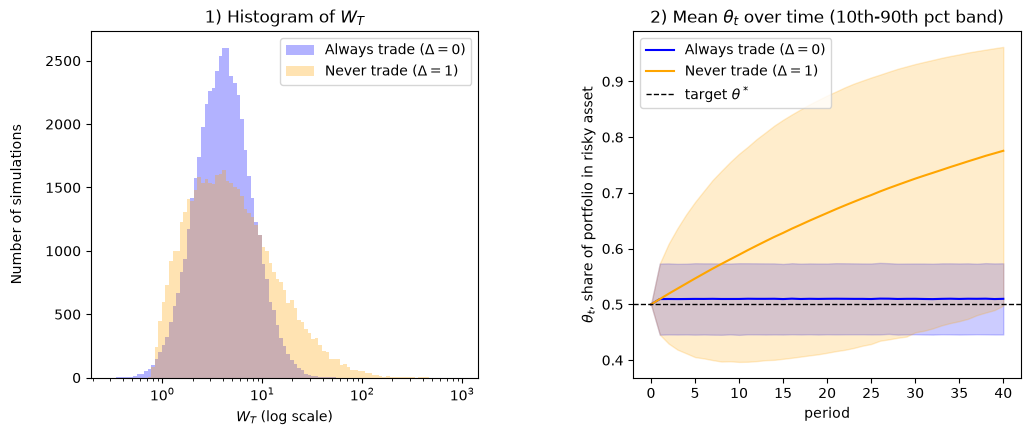

In [7]:
# Creating a figure with two panels to compare the two trading rules

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# panel 1:histogram of wealth for the two rules, log scale on x-axis
ax = axes[0]
wealth_always = model_always.sim.W[:, -1] 
wealth_never = model_never.sim.W[:, -1]

# Determine the min and max wealth across both strategies to set the bins for the histogram
wealth_min = min(wealth_always.min(), wealth_never.min())
wealth_max = max(wealth_always.max(), wealth_never.max())
bins = np.logspace(np.log10(wealth_min), np.log10(wealth_max), 100)    # log-spaced bins are used because terminal wealth is right-skewed with a long tail, which would otherwise be hard to see on a linear scale

# Plot the histograms for both rules with transparency and labels
ax.hist(wealth_always, bins= bins, alpha=0.3, label='Always trade ($\\Delta=0$)', color='blue')
ax.hist(wealth_never, bins= bins, alpha=0.3, label='Never trade ($\\Delta=1$)', color='orange')
ax.set_xscale('log')

ax.set_title('1) Histogram of $W_T$')
ax.set_xlabel('$W_T$ (log scale)', labelpad = 5)
ax.set_ylabel('Number of simulations', labelpad = 15)
ax.legend()

# panel 2: mean theta_t over time, with 10th-90th percentile band
ax = axes[1]
t = np.arange(model.par.T + 1)

# Compute mean and percentiles of theta_t for both trading rules
theta_always = model_always.sim.theta
theta_never = model_never.sim.theta

mean_always = np.mean(theta_always, axis=0)
p10_always = np.percentile(theta_always, 10, axis=0)
p90_always = np.percentile(theta_always, 90, axis=0)

mean_never = np.mean(theta_never, axis=0)
p10_never = np.percentile(theta_never, 10, axis=0)
p90_never = np.percentile(theta_never, 90, axis=0)

# Plot the mean and 10th-90th percentile bands for both trading rules
ax.plot(t, mean_always, color='blue', label='Always trade ($\\Delta=0$)')
ax.fill_between(t, p10_always, p90_always, color='blue', alpha=0.2)   # fill_between shows the range where about 80% of the simulated portfolios lie at each period

ax.plot(t, mean_never, color='orange', label='Never trade ($\\Delta=1$)')
ax.fill_between(t, p10_never, p90_never, color='orange', alpha=0.2)

ax.axhline(model.par.theta_star, color='black', linestyle='--', linewidth=1, label='target $\\theta^*$')
ax.set_title('2) Mean $\\theta_t$ over time (10th-90th pct band)')
ax.set_xlabel('period')
ax.set_ylabel('$\\theta_t$, share of portfolio in risky asset')
ax.legend()


fig.subplots_adjust(wspace=0.4)

plt.show()

1) The first panel shows the distribution of terminal wealth for the two strategies after 40 periods. The always-trade strategy has a higher and narrower peak, meaning that many of the simulated portfolios end with similar levels of wealth. This is because the portfolio is regularly rebalanced back towards the target of 50% in the risky asset and 50% in the safe asset, which limits how much the risky share can change over time.
The never-trade strategy has a wider distribution, meaning that there is more variation in terminal wealth across the simulated portfolios. Without rebalancing, the risky share can increase or decrease depending on how the risky asset performs. In simulations where the risky asset performs very well, it can become a large part of the portfolio and lead to very high terminal wealth. This creates the long right tail in the distribution and helps explain why the never-trade strategy has a higher average terminal wealth (8.98 compared to 5.04). However, the wider distribution also shows that the outcomes are less stable. This is also reflected in the 10th percentile of terminal wealth, which is higher for the always-trade strategy (1.79) than for the never-trade strategy (1.49), confirming that always-trade performs better in the worst-case scenarios.

2) The second panel shows the share of the portfolio invested in the risky asset over time for the two strategies. The always-trade strategy keeps the risky share close to the target of 50% because the portfolio is regularly rebalanced. In contrast, with the never-trade strategy, the risky share is allowed to change freely. Since the risky asset has a higher return on average than the safe asset, its value can grow faster and therefore make up a larger share of the portfolio over time. Because there is no rebalancing, the portfolio is not adjusted back towards the 50% target.
The shaded areas show the range between the 10th and 90th percentiles of the risky share across the simulated portfolios. This means that about 80% of the simulated risky shares are between the lower and upper boundaries of the shaded area at each period. The orange area becomes much wider over time, showing that the risky share varies considerably across the never-trade portfolios. Some portfolios end up with a very high risky share, while others have a much lower risky share. The always-trade strategy has a much narrower area because regular rebalancing keeps the portfolios closer to the 50% target.

### Question 3.3

In this question, we set the transaction cost to 0.01 and test nine different values of Delta, from always trading (Delta = 0) to never trading (Delta = 1). For each value, we report the six required numbers in a table, and plot how the number of trades, the distance to target, and expected utility depend on Delta. We then identify which Delta gives the best outcome.

In [8]:
# Report the six numbers for nine values of Delta, with tau = 0.01

deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]
rows = []

# Creating the loop to simulate the portfolio model for each value of Delta and store the results in a list of dictionaries

for delta in deltas:
    m = PortfolioModelClass(Delta=delta, tau=0.01)
    m.simulate(R=R)
    s = m.summary()
    rows.append({
        'Delta': delta,
        'n_trades': s.n_trades,
        'avg_dist': s.avg_dist,
        'mean_WT': s.mean_WT,
        'median_WT': s.median_WT,
        'p10_WT': s.p10_WT,
        'EU': s.EU
    })

table = pd.DataFrame(rows).set_index('Delta')
table.round(4)


,n_trades,avg_dist,mean_WT,median_WT,p10_WT,EU
Delta,,,,,,
0.000,39.0000,0.0394,4.9624,4.0184,1.7683,-0.0699
0.025,24.5235,0.0400,4.9746,4.0184,1.7692,-0.0697
0.050,14.3334,0.0429,5.0155,4.0358,1.7674,-0.0695
0.075,8.7905,0.0480,5.0739,4.0476,1.7655,-0.0693
0.100,5.8603,0.0541,5.1459,4.0606,1.7594,-0.0695
0.150,3.1519,0.0680,5.3285,4.1042,1.7353,-0.0700
0.200,1.9503,0.0835,5.5596,4.1863,1.6792,-0.0709
0.300,0.9055,0.1180,6.1957,4.3414,1.5361,-0.0734
1.000,0.0000,0.1911,8.9756,4.4478,1.4855,-0.0767


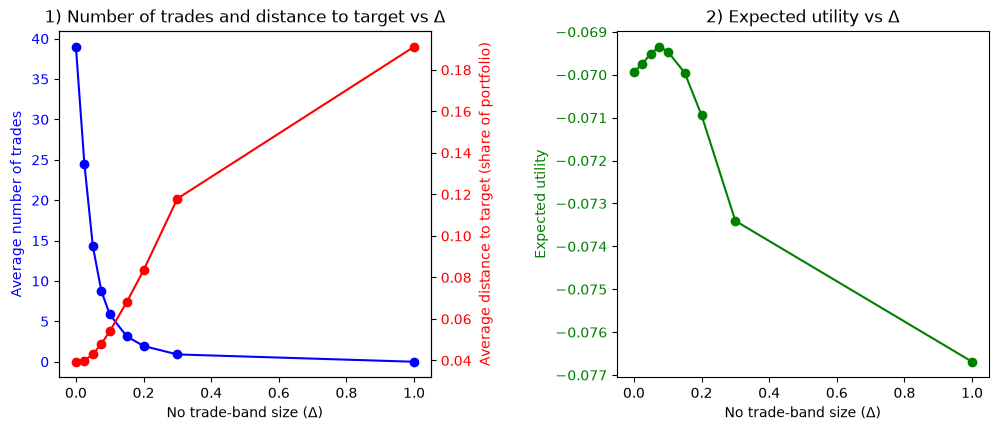

In [9]:
# Creating a figure with 2 panels 

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# panel 1:  number of trades and average distance to target against Delta with two y-axes because of different scales

ax1 = axes[0]

ax1.plot(table.index, table['n_trades'], color='blue', marker='o', label='n_trades')
ax1.set_xlabel('No trade-band size ($\\Delta$)')
ax1.set_ylabel('Average number of trades', color='blue', labelpad = 5)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()       # Creating a second y-axis for the average distance to target
ax2.plot(table.index, table['avg_dist'], color='red', marker='o', label='avg_dist')
ax2.set_ylabel('Average distance to target (share of portfolio)', color='red', labelpad = 5)
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('1) Number of trades and distance to target vs $\\Delta$')

# panel 2: expected utility against Delta
ax = axes[1]
ax.plot(table.index, table['EU'], color='green', marker='o')
ax.set_xlabel('No trade-band size ($\\Delta$)')
ax.set_ylabel('Expected utility', color = 'green', labelpad = 5)
ax.tick_params(axis='y', labelcolor='green')
ax.set_title('2) Expected utility vs $\\Delta$')


fig.subplots_adjust(wspace=0.5)

plt.show()


1) The first panel shows the relationship between the size of the no-trade band and how often the investor trades, as well as how far the portfolio moves from the target of 50% in the risky asset. The blue line shows the average number of trades, while the red line shows the average distance from the target. As expected, the number of trades decreases as the no-trade band becomes larger, because the investor allows the portfolio to move further away from the target before trading. At the same time, the average distance from the target increases as the no-trade band becomes larger, meaning that the portfolio, on average, moves further away from the target of 50% in the risky asset.

2) The second panel shows how the size of the no-trade band affects expected utility. Expected utility first increases and reaches its highest value at Delta = 0.075. After this point, expected utility starts to decrease. This suggests that a small no-trade band is better than always trading or never trading. It gives a good balance between reducing trading costs and keeping the portfolio close to the target. The improvement in expected utility is small compared to always trading (Delta = 0), from -0.0699 to -0.0693 with a gain of about 0.0006. The improvement compared to never trading (Delta = 1) is much larger, from -0.0767 to -0.0693, with a gain of about 0.0074.


### What happens if Delta grows? 

As Delta grows, the investor trades less often, and the risky share drifts further from the target. This increases risk, but also increases the average return.

Going from Delta = 0 to the best outcome of Delta when Delta is equal to 0.075, the number of trades drops a lot (39 to about 8.8), and the average distance from the target grows a bit (0.039 to 0.048). But expected utility barely changes (-0.0699 to -0.0693), and the other wealth numbers (mean, median, 10th percentile) also stay almost the same. This is why Delta = 0.075 is the better pick, it gives almost the same expected utility as always trading, but requires far less trades which means lower transaction costs for almost no loss in performance. 

Always trading (Delta = 0) is not wrong, but can be wasteful, since it pays transaction costs for something that doesn't significantly improves the outcome. Never trading (Delta = 1) looks attractive if you only look at average wealth, but is clearly the worst choice once risk is taken into account, since a risk-averse investor cares about the whole distribution of outcomes, not just the average. 

To answer the last question in 3.3.4: No, if we were able to choose which Delta to use (that is how often to actively rebalance the portfolio), we would not go with the rule that gives the highest mean terminal wealth. The mean is highest at Delta = 1, but we know this comes with the highest risk, and does not necessarily mean the highest utility. Instead, we would pick Delta = 0.075, since we know it gives the highest expected utility of all the rules tested, while requiring far fewer trades and therefore lower transaction costs, than Delta = 0.
